{'topic': '猫咪', 'poem': AIMessage(content='## 《猫》\n\n如流水般穿过长廊的尾巴\n在深夜惊醒了沉睡的古琴\n琴弦上晃动着脚步\n缓慢的\n像下过雨的青石路\n\n它跃上月亮图案的坐垫\n把脸埋进温暖的梦境中\n胡须轻轻颤动\n与窗外柳树的枝条\n进行只有它们才懂的游戏\n\n风来时\n它把身子团成一个句号\n像在说：\n别打扰这段时光\n得慢慢消受\n\n在整夜都不灭的街灯下\n万物都终于睡去\n只有这只猫\n在墙上画出柔和的弧线\n像一个活着的漩涡\n停驻在梦与醒之间的路\n缓缓转动', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 142, 'prompt_tokens': 10, 'total_tokens': 152, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 10}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'c683ccdc-bbf5-4c0f-bd7d-a85b8aa2622e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019fa4f1-bebc-72c3-9013-cd52c8eaf64a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 10, 'output_tokens': 142, 'total_tokens': 152, 'input_token_details': {'c

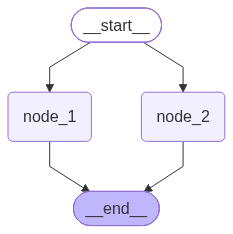

In [1]:
# -*- coding: utf-8 -*-
# 【CP2-01 扇出并行】START 同时触发多节点，并行写不同字段
# 文件：CP2/01_parallel.ipynb
# 作用：本 Cell 演示 【CP2-01 扇出并行】START 同时触发多节点，并行写不同字段 的完整可运行示例
# 阅读顺序：状态定义 → 节点定义 → 图构建 → 编译执行 → 结果观察

from dotenv import load_dotenv
from typing import TypedDict
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph,START,END    
from typing import TypedDict, Annotated
load_dotenv()

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body={        
        "thinking":{
            "type":"disabled"
        }
    }
)

# 1 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

def node_1(state : OverAllState) -> OverAllState:
    # 向全局状态添加poem
    return {
        "poem": model.invoke(f"请写一首关于{state['topic']}的诗"),  # AND 汇合：需全部前驱完成才触发下游
    }

def node_2(state : OverAllState) -> OverAllState:
    # 向全局状态添加joke
    return {
        "joke": model.invoke(f"请写一个关于{state['topic']}的笑话"),  # AND 汇合：需全部前驱完成才触发下游
    }

# 2 构建状态图
builder = StateGraph(state_schema=OverAllState)  # 创建状态图构建器：绑定状态 Schema
builder.add_node("node_1", node_1)  # 注册节点到图中
builder.add_node("node_2", node_2)  # 注册节点到图中
builder.add_edge(START, "node_1")  # 起点扇出
builder.add_edge(START, "node_2")  # 起点扇出

graph = builder.compile()  # 编译图：蓝图→可执行对象

result = graph.invoke({"topic": "猫咪"})  # 触发图执行：传入初始 State + config
print(result)

from IPython.display import display
display(graph)
